In [ ]:
from google.colab import files

print("Upload FIRST sepsis dataset")
uploaded1 = files.upload()

print("Upload SECOND sepsis dataset")
uploaded2 = files.upload()

Upload FIRST sepsis dataset


Saving sepsis_dataset1.csv to sepsis_dataset1.csv
Upload SECOND sepsis dataset


Saving Dataset.csv to Dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sepsis1 = pd.read_csv("sepsis_dataset1.csv")
sepsis2 = pd.read_csv("Dataset.csv")

print("Dataset 1 Shape:", sepsis1.shape)
print("Dataset 2 Shape:", sepsis2.shape)

Dataset 1 Shape: (1946, 32)
Dataset 2 Shape: (1552210, 44)


In [ ]:
sepsis1.head()
sepsis2.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [ ]:
print("Columns in Dataset 1:")
print(sepsis1.columns)

print("\nColumns in Dataset 2:")
print(sepsis2.columns)

Columns in Dataset 1:
Index(['episode_id', 'unique_patient_id', 'sex', 'race',
       'gestational_age_at_birth_weeks', 'birth_weight_kg', 'sepsis_group',
       'onset_age_in_days', 'onset_hour_of_day', 'blood_culture_positive',
       'positive_days', 'cx_site', 'time_to_antibiotics', 'stat_abx',
       'overall_mortality_within_7_days', 'overall_mortality_within_14_days',
       'overall_mortality_within_30_days',
       'intubated_at_time_of_sepsis_evaluation', 'intubated_free_days',
       'inotrope_at_time_of_sepsis_eval', 'inotrope_free_days',
       'central_venous_line', 'umbilical_arterial_line', 'ecmo',
       'temp_celsius', 'length_of_stay_hours',
       'comorbidity_necrotizing_enterocolitis',
       'comorbidity_chronic_lung_disease', 'comorbidity_cardiac',
       'comorbidity_surgical', 'comorbidity_ivh_or_shunt', 'period'],
      dtype='object')

Columns in Dataset 2:
Index(['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP',
       'Resp', 'EtCO2', 'Base

In [ ]:
sepsis2 = sepsis2.drop(columns=["Unnamed: 0"], errors="ignore")

In [ ]:
#----------------------------------------------#
    #sepsis-model1#
#----------------------------------------------#

In [ ]:
sepsis1.isnull().sum()

,0
episode_id,0
unique_patient_id,0
sex,0
race,0
gestational_age_at_birth_weeks,15
birth_weight_kg,52
sepsis_group,0
onset_age_in_days,0
onset_hour_of_day,0
blood_culture_positive,0


In [ ]:
# Fill numerical missing values with median
sepsis1["gestational_age_at_birth_weeks"].fillna(sepsis1["gestational_age_at_birth_weeks"].median(), inplace=True)
sepsis1["birth_weight_kg"].fillna(sepsis1["birth_weight_kg"].median(), inplace=True)
sepsis1["temp_celsius"].fillna(sepsis1["temp_celsius"].median(), inplace=True)
sepsis1["length_of_stay_hours"].fillna(sepsis1["length_of_stay_hours"].median(), inplace=True)

# Fill categorical column with mode
sepsis1["cx_site"].fillna(sepsis1["cx_site"].mode()[0], inplace=True)

/tmp/ipykernel_407/894826975.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sepsis1["gestational_age_at_birth_weeks"].fillna(sepsis1["gestational_age_at_birth_weeks"].median(), inplace=True)
/tmp/ipykernel_407/894826975.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ["sex", "race", "cx_site", "period"]

for col in categorical_cols:
    sepsis1[col] = le.fit_transform(sepsis1[col])

In [ ]:
X1 = sepsis1.drop(columns=["sepsis_group"])
y1 = sepsis1["sepsis_group"]

In [ ]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier(n_estimators=100, random_state=42)

model1.fit(X1_train, y1_train)

RandomForestClassifier(random_state=42)

In [ ]:
y1_pred = model1.predict(X1_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


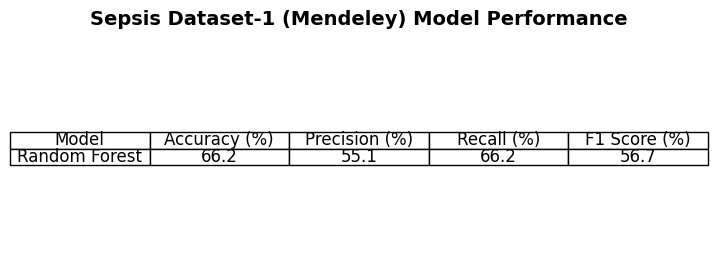

In [ ]:
import matplotlib.pyplot as plt

table_data = [[
    "Random Forest",
    round(accuracy_score(y1_test, y1_pred)*100,1),
    round(precision_score(y1_test, y1_pred, average='weighted')*100,1),
    round(recall_score(y1_test, y1_pred, average='weighted')*100,1),
    round(f1_score(y1_test, y1_pred, average='weighted')*100,1)
]]

columns = ["Model", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)"]

fig, ax = plt.subplots(figsize=(9,3))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1,1)

plt.title("Sepsis Dataset-1 (Mendeley) Model Performance", fontsize=14, fontweight='bold')

plt.show()

In [ ]:
#----------------------------------------------#
    #sepsis-model2#
#----------------------------------------------#

In [ ]:
sepsis2.isnull().sum()

,0
Hour,0
HR,153399
O2Sat,202736
Temp,1026984
SBP,226265
MAP,193270
DBP,486554
Resp,238335
EtCO2,1494574
BaseExcess,1468065


In [ ]:
sepsis2 = sepsis2.fillna(sepsis2.median(numeric_only=True))

In [ ]:
X2 = sepsis2.drop(columns=["SepsisLabel"])
y2 = sepsis2["SepsisLabel"]

In [ ]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(n_estimators=30, random_state=42)

model2.fit(X2_train, y2_train)

RandomForestClassifier(n_estimators=30, random_state=42)

In [ ]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X2_train, y2_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
#Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X2_train, y2_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Predictions for Dataset 2 models

rf_pred = model2.predict(X2_test)

log_pred = log_model.predict(X2_test)

dt_pred = dt_model.predict(X2_test)

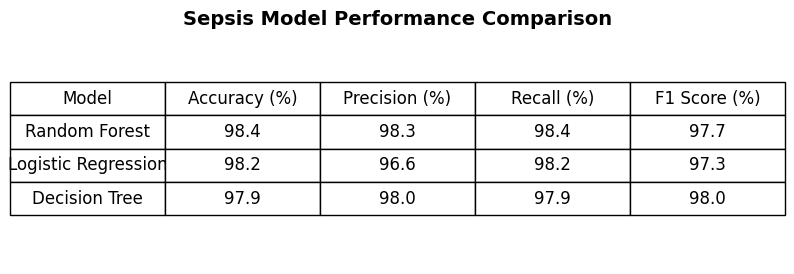

In [ ]:
import matplotlib.pyplot as plt

table_data = [
    ["Random Forest",
     round(accuracy_score(y2_test, rf_pred)*100,1),
     round(precision_score(y2_test, rf_pred, average='weighted')*100,1),
     round(recall_score(y2_test, rf_pred, average='weighted')*100,1),
     round(f1_score(y2_test, rf_pred, average='weighted')*100,1)],

    ["Logistic Regression",
     round(accuracy_score(y2_test, log_pred)*100,1),
     round(precision_score(y2_test, log_pred, average='weighted')*100,1),
     round(recall_score(y2_test, log_pred, average='weighted')*100,1),
     round(f1_score(y2_test, log_pred, average='weighted')*100,1)],

    ["Decision Tree",
     round(accuracy_score(y2_test, dt_pred)*100,1),
     round(precision_score(y2_test, dt_pred, average='weighted')*100,1),
     round(recall_score(y2_test, dt_pred, average='weighted')*100,1),
     round(f1_score(y2_test, dt_pred, average='weighted')*100,1)]
]

columns = ["Model", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)"]

fig, ax = plt.subplots(figsize=(10,3))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1,2)

plt.title("Sepsis Model Performance Comparison", fontsize=14, fontweight='bold')

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


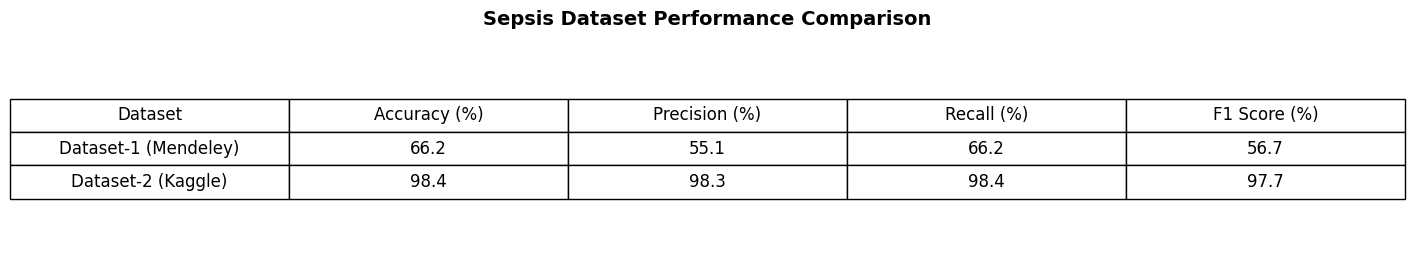

In [ ]:
import matplotlib.pyplot as plt

table_data = [
    ["Dataset-1 (Mendeley)",
     round(accuracy_score(y1_test, y1_pred)*100,1),
     round(precision_score(y1_test, y1_pred, average='weighted')*100,1),
     round(recall_score(y1_test, y1_pred, average='weighted')*100,1),
     round(f1_score(y1_test, y1_pred, average='weighted')*100,1)],

    ["Dataset-2 (Kaggle)",
     round(accuracy_score(y2_test, rf_pred)*100,1),
     round(precision_score(y2_test, rf_pred, average='weighted')*100,1),
     round(recall_score(y2_test, rf_pred, average='weighted')*100,1),
     round(f1_score(y2_test, rf_pred, average='weighted')*100,1)]
]

columns = ["Dataset", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)"]

fig, ax = plt.subplots(figsize=(9,3))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2,2)

plt.title("Sepsis Dataset Performance Comparison", fontsize=14, fontweight='bold')

plt.show()

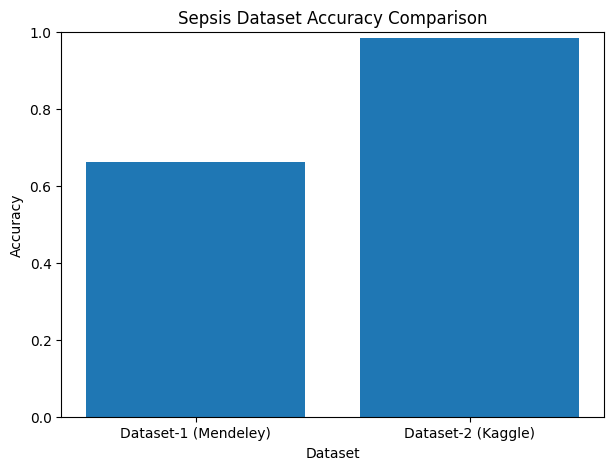

In [ ]:
datasets = ["Dataset-1 (Mendeley)", "Dataset-2 (Kaggle)"]

accuracies = [
    accuracy_score(y1_test, y1_pred),
    accuracy_score(y2_test, rf_pred)
]

plt.figure(figsize=(7,5))

plt.bar(datasets, accuracies)

plt.title("Sepsis Dataset Accuracy Comparison")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


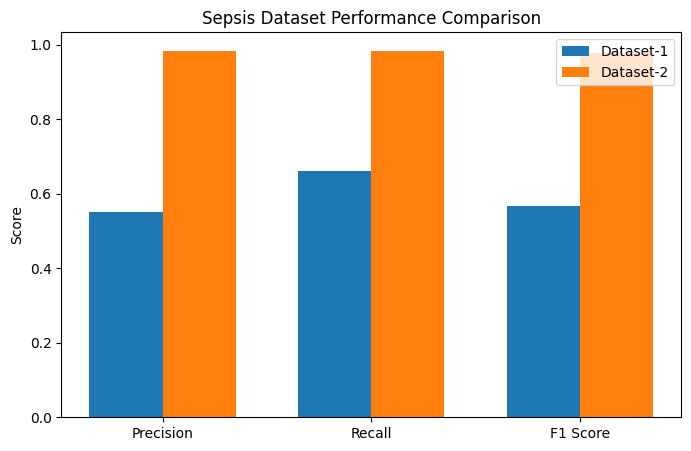

In [ ]:
import numpy as np

metrics = ["Precision", "Recall", "F1 Score"]

dataset1_scores = [
    precision_score(y1_test, y1_pred, average='weighted'),
    recall_score(y1_test, y1_pred, average='weighted'),
    f1_score(y1_test, y1_pred, average='weighted')
]

dataset2_scores = [
    precision_score(y2_test, rf_pred, average='weighted'),
    recall_score(y2_test, rf_pred, average='weighted'),
    f1_score(y2_test, rf_pred, average='weighted')
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, dataset1_scores, width, label="Dataset-1")
plt.bar(x + width/2, dataset2_scores, width, label="Dataset-2")

plt.xticks(x, metrics)

plt.title("Sepsis Dataset Performance Comparison")
plt.ylabel("Score")

plt.legend()

plt.show()

In [ ]:
feature_importance = pd.Series(model2.feature_importances_, index=X2.columns)

In [ ]:
!pip install joblib scikit-learn

In [ ]:
model2 = RandomForestClassifier(n_estimators=30, random_state=42)
model2.fit(X2_train, y2_train)

RandomForestClassifier(n_estimators=30, random_state=42)

In [ ]:
import joblib

joblib.dump(model2, "sepsis_model.pkl")

['sepsis_model.pkl']

In [ ]:
from google.colab import files

files.download("sepsis_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>